### Import Packages & Load .csv Files

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

CORPUS = pd.read_csv("CORPUS.csv", sep="|")
LIB = pd.read_csv("LIB.csv", sep="|")
VOCAB = pd.read_csv("VOCAB.csv", sep="|")

### VOCAB_W2V

In [6]:
# Rebuild tokenized documents
sentences = (
    CORPUS
    .sort_values(["doc_id", "token_id"])
    .groupby("doc_id")["term_str"]
    .apply(lambda x: x.astype(str).tolist())
    .tolist()
)

# Train Word2Vec model
vector_size = 100

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=vector_size,
    window=5,
    min_count=2,
    workers=4,
    sg=1,          
    seed=0
)

# Build VOCAB_W2V table
w2v_terms = set(w2v_model.wv.index_to_key)

VOCAB_W2V = VOCAB[
    VOCAB["term_str"].astype(str).isin(w2v_terms)
].copy()

for i in range(vector_size):
    VOCAB_W2V[f"w2v_{i:03d}"] = VOCAB_W2V["term_str"].astype(str).apply(
        lambda term: w2v_model.wv[term][i]
    )

# Save output
VOCAB_W2V.to_csv("VOCAB_W2V.csv", sep="|", index=False)

VOCAB_W2V.head()

C:\Users\Linoalot\AppData\Local\Temp\ipykernel_12352\1231264011.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  VOCAB_W2V[f"w2v_{i:03d}"] = VOCAB_W2V["term_str"].astype(str).apply(
C:\Users\Linoalot\AppData\Local\Temp\ipykernel_12352\1231264011.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  VOCAB_W2V[f"w2v_{i:03d}"] = VOCAB_W2V["term_str"].astype(str).apply(
C:\Users\Linoalot\AppData\Local\Temp\ipykernel_12352\1231264011.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

,term_str,n,max_pos,max_pos_group,p,i,df,dfidf,porter_stem,stop,...,w2v_090,w2v_091,w2v_092,w2v_093,w2v_094,w2v_095,w2v_096,w2v_097,w2v_098,w2v_099
0,a,25889,DT,OTHER,0.029838,5.066690,5332,27015.593260,a,True,...,-0.053132,0.471620,0.177183,-0.376750,-0.061985,0.203773,0.189318,0.203174,0.286798,0.374493
1,aapl,2,NNP,NOUN,0.000002,18.726742,2,37.453484,aapl,False,...,-0.029909,0.045237,0.118133,-0.132711,-0.072862,0.062264,0.023101,0.007589,-0.145124,0.104379
3,ab,4,NNP,NOUN,0.000005,17.726742,4,70.906968,ab,False,...,-0.016408,0.051637,0.199026,-0.114132,-0.102191,0.072134,-0.027064,0.080937,-0.176093,0.141639
5,abandoned,7,VBN,VERB,0.000008,16.919387,7,118.435710,abandon,False,...,-0.096702,-0.041900,0.250759,-0.226031,-0.045881,0.074805,-0.007761,0.084873,-0.190838,0.122105
6,abandoning,2,VBG,VERB,0.000002,18.726742,2,37.453484,abandon,False,...,-0.024910,0.013998,0.122797,-0.116004,-0.077817,0.108665,-0.032018,0.027282,-0.102359,0.127580


### Word2vec tSNE Plot

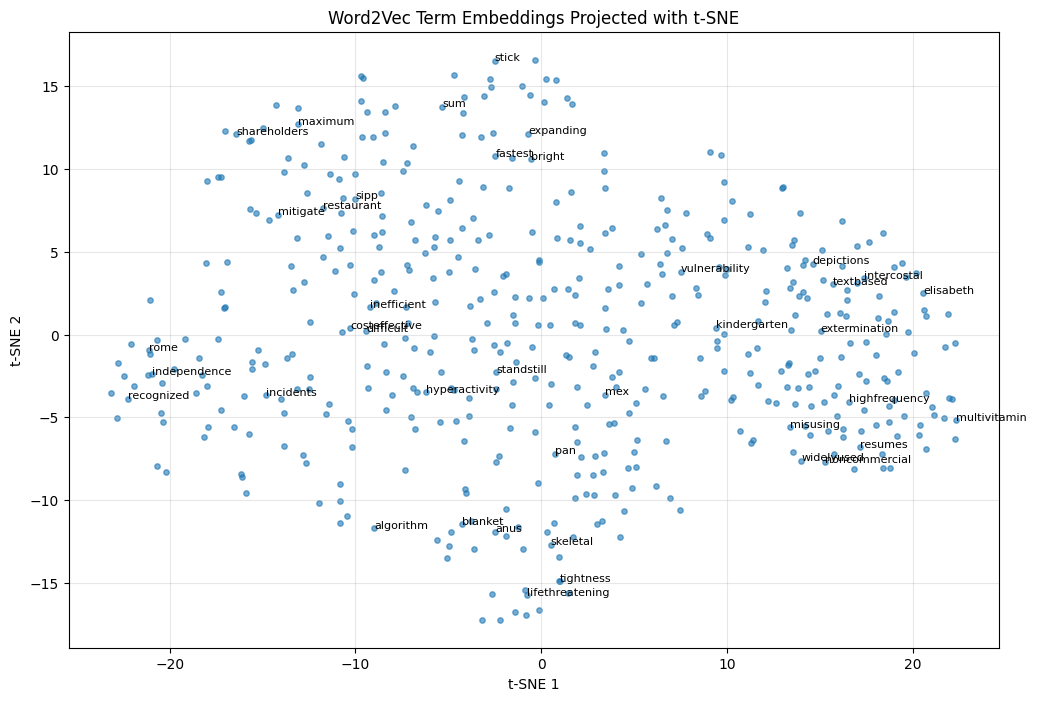

In [ ]:
# Load Word2Vec features
VOCAB_W2V = pd.read_csv("VOCAB_W2V.csv", sep="|")

# Select embedding columns
w2v_cols = [col for col in VOCAB_W2V.columns if col.startswith("w2v_")]

# Sample terms so plot is not too crowded
VOCAB_W2V_PLOT = VOCAB_W2V.sample(
    n=min(500, len(VOCAB_W2V)),
    random_state=0
).copy()

X = VOCAB_W2V_PLOT[w2v_cols].values

# Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=0,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

VOCAB_W2V_PLOT["TSNE1"] = X_tsne[:, 0]
VOCAB_W2V_PLOT["TSNE2"] = X_tsne[:, 1]

# Plot
plt.figure(figsize=(12, 8))

plt.scatter(
    VOCAB_W2V_PLOT["TSNE1"],
    VOCAB_W2V_PLOT["TSNE2"],
    alpha=0.6,
    s=15
)

# Label a subset of words so the plot is readable
for _, row in VOCAB_W2V_PLOT.sample(
    n=min(40, len(VOCAB_W2V_PLOT)),
    random_state=1
).iterrows():
    plt.text(
        row["TSNE1"],
        row["TSNE2"],
        row["term_str"],
        fontsize=8
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Word2Vec Term Embeddings Projected with t-SNE")
plt.grid(True, alpha=0.3)

plt.show()